In [ ]:
# ДОМАШАНЕЕ ЗАДАНИЕ
# Текстурные характеристики:
#  - Реализуйте подсчет гистограммы
#  - Реализуйте рассчет текстурных характеристик Laws
#  - Реализуйте расчет текстурных характеристик на основе матрицы взаимной встречаемости GLCM
# Для каждого случая: выполните тренировку классификатора (knn, svm, trees)
# Решите задачу сегментации данных на основе классификации изображений каждым методом.
# Выполните ручную разметку изображений на регионы.
# Сравните результат полученной классификации и размеченной.

Найдено изображений: 6
 1. /content/3.jpg
 2. /content/4.jpg
 3. /content/5.png
 4. /content/6.png
 5. /content/images (1).jfif
 6. /content/images (2).jfif
Загружено изображений: 6

=== РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (по всем файлам) ===
Histogram + kNN: accuracy=1.00
                 precision    recall  f1-score   support

          3.jpg       1.00      1.00      1.00         1
          4.jpg       1.00      1.00      1.00         1
          5.png       1.00      1.00      1.00         1
          6.png       1.00      1.00      1.00         1
images (1).jfif       1.00      1.00      1.00         1
images (2).jfif       1.00      1.00      1.00         1

       accuracy                           1.00         6
      macro avg       1.00      1.00      1.00         6
   weighted avg       1.00      1.00      1.00         6

Histogram + SVM: accuracy=1.00
                 precision    recall  f1-score   support

          3.jpg       1.00      1.00      1.00         1
          4.jpg  

/tmp/ipython-input-4172478541.py:141: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  seg[y//patch,x//patch] = model.predict(f)
/tmp/ipython-input-4172478541.py:141: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  seg[y//patch,x//patch] = model.predict(f)
/tmp/ipython-input-4172478541.py:141: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  seg[y//patch,x//patch] = model.predict(f)
/tmp/ipython-input-4172478541.py:141: DeprecationWarning: Conversion of an array with ndim 

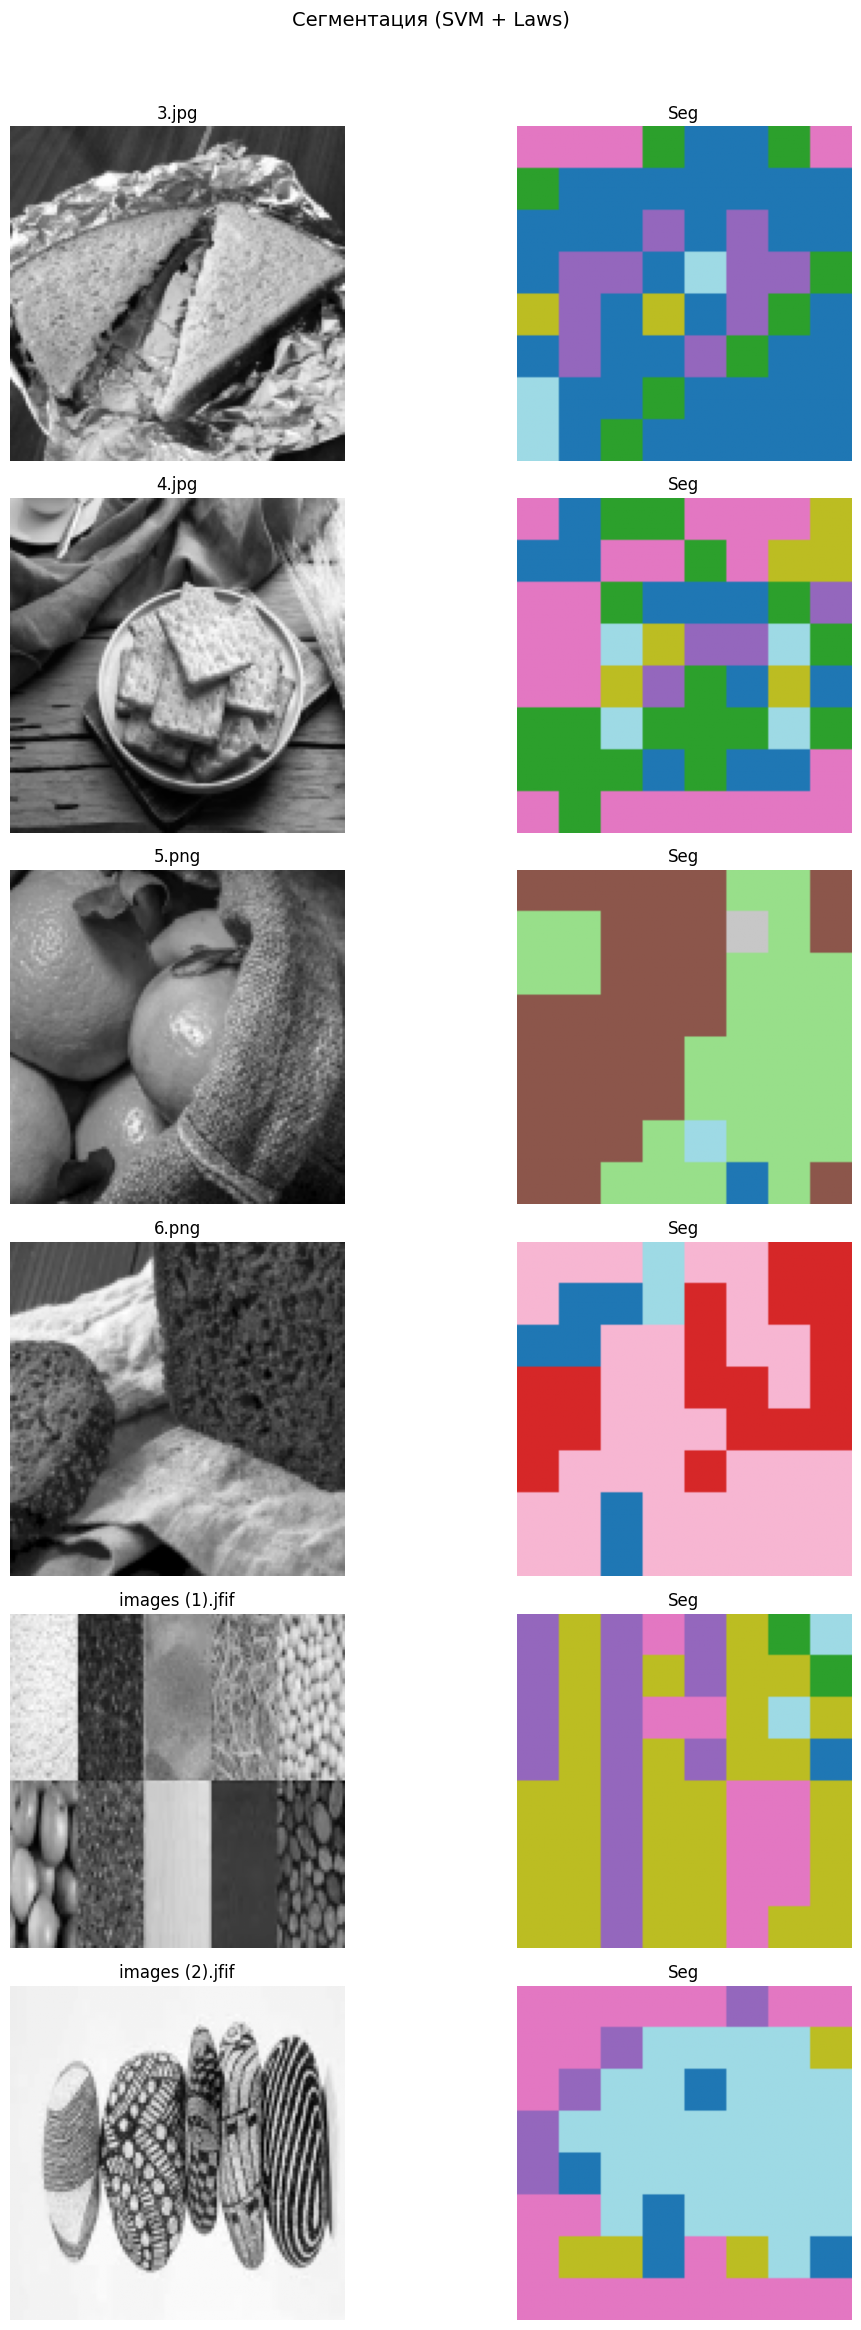

In [34]:
import os, cv2, math, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
def _import_glcm():
    try:
        from skimage.feature.texture import graycomatrix, graycoprops
        return graycomatrix, graycoprops
    except Exception:
        pass
    try:
        from skimage.feature.texture import greycomatrix as graycomatrix, greycoprops as graycoprops
        return graycomatrix, graycoprops
    except Exception:
        pass
    try:
        from skimage.feature import graycomatrix, graycoprops
        return graycomatrix, graycoprops
    except Exception:
        from skimage.feature import greycomatrix as graycomatrix, greycoprops as graycoprops
        return graycomatrix, graycoprops

graycomatrix, graycoprops = _import_glcm()
from skimage import img_as_ubyte

#НАСТРОЙКИ
SEARCH_DIRS = ["/content/data", "/content"]
EXCLUDE_DIRS = {"seg", "sample_data", ".ipynb_checkpoints", "__pycache__"}
EXTS = (".jpg", ".jpeg", ".png", ".jfif", ".bmp", ".tif", ".tiff")
TARGET_SIZE = (128, 128)
PATCH = 16
# ПОИСК ФАЙЛОВ
def find_images():
    files = []
    for base in SEARCH_DIRS:
        if not os.path.exists(base):
            continue
        for root, _, names in os.walk(base):
            # пропускаем служебные папки
            rel_parts = os.path.relpath(root, "/content").split(os.sep)
            if any(p in EXCLUDE_DIRS for p in rel_parts):
                continue
            for n in names:
                n_low = n.lower()
                if n_low.endswith(EXTS) and not n_low.startswith("seg_"):
                    files.append(os.path.join(root, n))
    return sorted(dict.fromkeys(files))

image_paths = find_images()
if len(image_paths) < 2:
    raise RuntimeError("Нужно минимум 2 изображения (.jpg/.jpeg/.png/.jfif/.bmp/.tif/.tiff) в /content или /content/data")

print(f"Найдено изображений: {len(image_paths)}")
for i,p in enumerate(image_paths[:10],1):
    print(f"{i:2d}. {p}")
if len(image_paths) > 10:
    print(f"... и ещё {len(image_paths)-10}")

#Чтение изображений
def read_gray(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Не удалось прочитать {path}")
    return cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)

images = [read_gray(p) for p in image_paths]
labels  = [f"image_{i+1}" for i in range(len(images))]   # одна метка = один файл

print("Загружено изображений:", len(images))

#Признаки
def feats_histogram(img, bins=32):
    hist = cv2.calcHist([img],[0],None,[bins],[0,256]).flatten()
    return hist / (hist.sum() + 1e-8)

def laws_kernels():
    L5 = np.array([1,4,6,4,1],dtype=np.float32)
    E5 = np.array([-1,-2,0,2,1],dtype=np.float32)
    S5 = np.array([-1,0,2,0,-1],dtype=np.float32)
    R5 = np.array([1,-4,6,-4,1],dtype=np.float32)
    W5 = np.array([-1,2,0,-2,1],dtype=np.float32)
    vectors = [L5,E5,S5,R5,W5]
    return [np.outer(v1,v2) for v1 in vectors for v2 in vectors]

def feats_laws(img):
    imgf = img.astype(np.float32)
    imgf -= cv2.blur(imgf,(15,15))
    energies = [cv2.blur(cv2.filter2D(imgf,-1,k)**2,(15,15)).mean() for k in laws_kernels()]
    return np.array(energies,np.float32)

def feats_glcm(img):
    g = graycomatrix(img_as_ubyte(img), [1,2,4],
                     [0,np.pi/4,np.pi/2,3*np.pi/4],
                     256, symmetric=True, normed=True)
    props = []
    for p in ("contrast","dissimilarity","homogeneity","ASM","energy","correlation"):
        props.extend(graycoprops(g,p).flatten())
    return np.array(props,np.float32)

#Признаковые матрицы
X_hist = np.vstack([feats_histogram(im) for im in images])
X_laws = np.vstack([feats_laws(im) for im in images])
X_glcm = np.vstack([feats_glcm(im) for im in images])
Y = np.arange(len(images))

#Классификаторы
models = {
    "kNN": KNeighborsClassifier(n_neighbors=1),
    "SVM": SVC(kernel='linear'),
    "Tree": DecisionTreeClassifier()
}

scaler = StandardScaler()

def train_and_report(X, name):
    Xs = scaler.fit_transform(X)
    for mname, model in models.items():
        model.fit(Xs, Y)
        preds = model.predict(Xs)
        acc = accuracy_score(Y, preds)
        print(f"{name} + {mname}: accuracy={acc:.2f}")
        print(classification_report(Y, preds, target_names=[os.path.basename(p) for p in image_paths]))
    print("-"*60)

print("\n=== РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (по всем файлам) ===")
train_and_report(X_hist, "Histogram")
train_and_report(X_laws, "Laws")
train_and_report(X_glcm, "GLCM")

#Простая сегментация всех изображений
def segment(img, model, feature_func, patch=PATCH):
    H,W = img.shape
    seg = np.zeros((H//patch, W//patch), dtype=np.int32)
    for y in range(0, H-patch+1, patch):
        for x in range(0, W-patch+1, patch):
            patch_img = img[y:y+patch,x:x+patch]
            f = feature_func(patch_img).reshape(1,-1)
            f = scaler.transform(f)
            seg[y//patch,x//patch] = model.predict(f)
    seg = cv2.resize(seg,(W,H),interpolation=cv2.INTER_NEAREST)
    return seg

#SVM + Laws
clf = models["SVM"]
clf.fit(scaler.fit_transform(X_laws), Y)

os.makedirs("/content/seg", exist_ok=True)

nrows, ncols = len(images), 2
plt.figure(figsize=(6*ncols, 3.8*nrows))
plt.suptitle("Cегментация (SVM + Laws)", y=1.02, fontsize=14)

for i, (im, pth) in enumerate(zip(images, image_paths), 1):
    seg = segment(im, clf, feats_laws, patch=PATCH)
    # сохраняем
    out_path = f"/content/seg/seg_SVM_Laws_{os.path.basename(pth)}.png"
    cv2.imwrite(out_path, seg)
    # рисуем
    plt.subplot(nrows, ncols, 2*i-1); plt.imshow(im, cmap='gray'); plt.title(os.path.basename(pth)); plt.axis("off")
    plt.subplot(nrows, ncols, 2*i);   plt.imshow(seg, cmap='tab20'); plt.title("Seg"); plt.axis("off")

plt.tight_layout(); plt.show()

In [ ]:
!rm -rf /content/seg
